Karpathy tutorial: https://www.youtube.com/watch?v=l8pRSuU81PU

## HuggingFace Transformer

https://huggingface.co/openai-community/gpt2

https://github.com/huggingface/transformers/blob/main/src/transformers/models/gpt2/modeling_gpt2.py

In [1]:
from transformers import GPT2LMHeadModel

gpt2_model_hf = GPT2LMHeadModel.from_pretrained("gpt2") # 124M parameters

gpt2_model_hf

ModuleNotFoundError: No module named 'transformers'

In [2]:
!nvidia-smi

/bin/bash: nvidia-smi: command not found


In [34]:
# for k, v in gpt2_model_hf.state_dict().items():
#     print(k, v.shape)

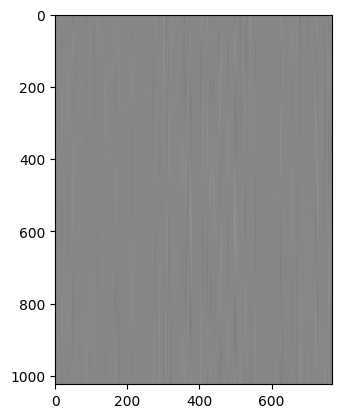

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(gpt2_model_hf.state_dict()["transformer.wpe.weight"], cmap="gray")

In [7]:
from transformers import pipeline, set_seed
generator = pipeline('text-generation', model='gpt2')
set_seed(42)
generator("Hello, I'm a language model,", max_length=30, num_return_sequences=5)


Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[{'generated_text': "Hello, I'm a language model, I'm writing a new language for you. But first, I'd like to tell you about the language itself"},
 {'generated_text': "Hello, I'm a language model, and I'm trying to be as expressive as possible. In order to be expressive, it is necessary to know"},
 {'generated_text': "Hello, I'm a language model, so I don't get much of a license anymore, but I'm probably more familiar with other languages on that"},
 {'generated_text': "Hello, I'm a language model, a functional model... It's not me, it's me!\n\nI won't bore you with how"},
 {'generated_text': "Hello, I'm a language model, not an object model.\n\nIn a nutshell, I need to give language model a set of properties that"}]

# GPT
![CleanShot 2024-09-23 at 08.28.07@2x.png](<attachment:CleanShot 2024-09-23 at 08.28.07@2x.png>)
![CleanShot 2024-09-23 at 08.27.40@2x.png](<attachment:CleanShot 2024-09-23 at 08.27.40@2x.png>)
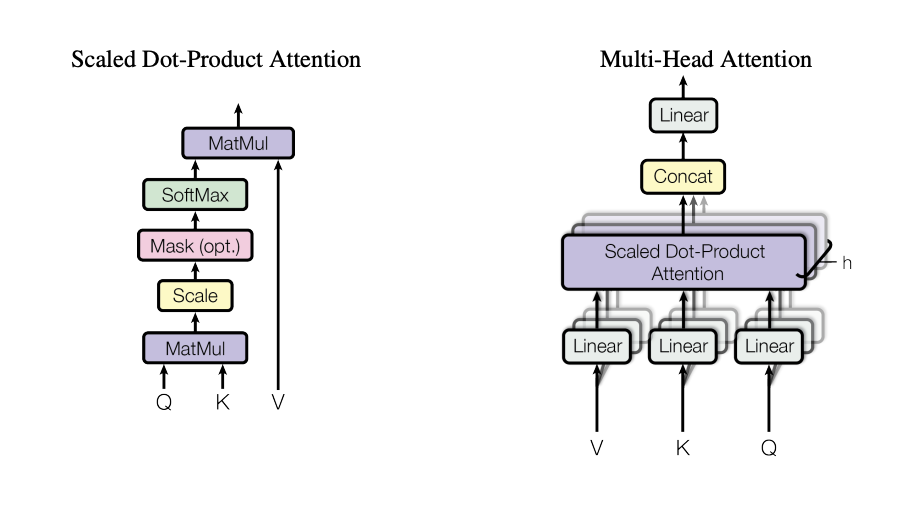
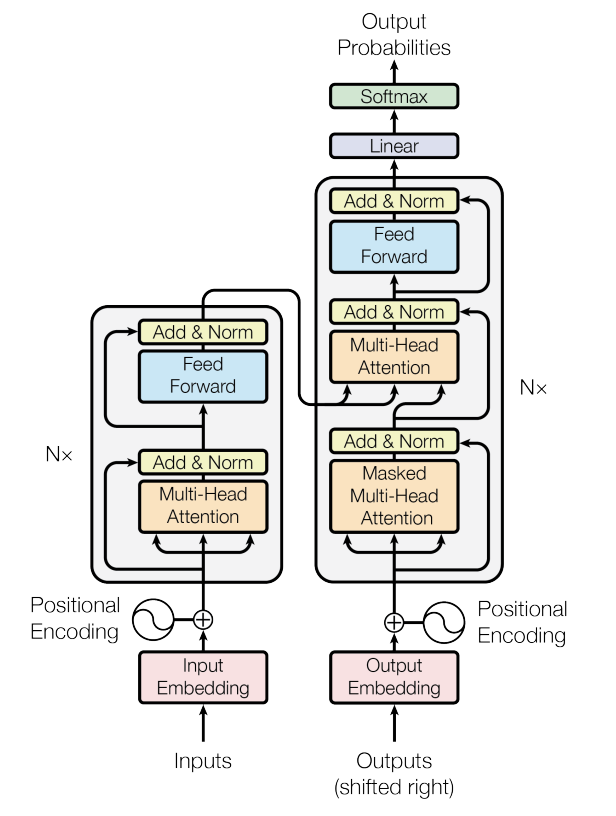

In [36]:
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as F
import math

@dataclass 
class GPTConfig:
    block_size: int = 1024 #max sequence length
    vocab_size: int = 50257 # number of token: 50k BPE merges + 256 byte tokens + 1 <|endoftext|> token (delimits documents)
    n_layer: int = 12 # number of layers
    n_head: int = 12 # number of heads
    n_embd: int = 768 # embedding dimension

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)
 
    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))     
        return x


class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd)
        self.gelu = nn.GELU(approximate='tanh')
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd)
        self.c_proj.RESIDUAL_SCALE_INIT = 1 # scaling weight initialization for training
    
    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.c_proj.RESIDUAL_SCALE_INIT = 1 # scaling weight initialization for training

        # regularization
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        # not really a bias, more of a mask - following OpenAI convention
        # this is introducing new params that are just for a mask
        # self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
        #                      .view(1, 1, config.block_size, config.block_size))
        
    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)
        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        # nh is "number of heads", hs is "head size", and C (number of channels) = nh * hs
        # e.g. in GPT-2 (124M), n_head=12, hs=64, so nh*hs=C=768 channels in the Transformer
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)

        # attention (materializes the large (T,T) matrix for all the queries and keys)
        # Substitute four operations for Flash Attention
        # att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        # att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        # att = F.softmax(att, dim=-1)
        # y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True) # flash attention

        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y
        

In [16]:
class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.block_size, config.n_embd),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = nn.LayerNorm(config.n_embd)
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # weight tie the embedding matrix with the unembedding matrix (language model head)
        # the layer that encodes from vocab size -> embedding dim is the same as the one that decodes from embedding dim -> vocab size
        self.transformer.wte.weight = self.lm_head.weight

        # init params
        self.apply(self._init_weights)
        
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            std = 0.02
            if hasattr(module, 'RESIDUAL_SCALE_INIT'):
                std *= (2 * self.config.n_layer) ** -0.5
            torch.nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        # idx is of shape (Batch size,Token sequence)
        B, T = idx.size()
        assert T <= self.config.block_size, f"Cannot forward sequence of length {T}"
        # forward the token and position embeddings
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape(T)
        pos_emb = self.transformer.wpe(pos) # position embeddings: (T, n_embd)
        tok_emb = self.transformer.wte(idx) # token embeddings: (T, n_embd)
        x = tok_emb + pos_emb
        # forward the blocks of the transformer
        for block in self.transformer.h:
            x = block(x)
        # final layernorm and the classifier
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x) # (B, T, vocab_size)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @classmethod
    def from_pretrained(cls, model_type):
        """Loads pretrained GPT-2 model weights from huggingface"""
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        # create a from-scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

In [26]:

device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
device = "cpu"

print(f"using device {device}")


num_return_seq = 5
max_length = 30
torch.manual_seed(42)

## Tokenize input
import tiktoken
enc = tiktoken.get_encoding('gpt2')
tokens = enc.encode("Hello, I'm a language model,")
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
tokens = tokens.unsqueeze(0).repeat(num_return_seq, 1) # (5,8)
x = tokens.to(device)

## Using our GPT model
model = GPT.from_pretrained('gpt2')
## Using our HuggingFace model
from transformers import GPT2LMHeadModel
model = GPT2LMHeadModel.from_pretrained("gpt2")
## Using a random model
model = GPT(GPTConfig(vocab_size=50304)) # set vocab size a bit larger than tokenizer to make it a nice power of 2 (not an ugly number anymore)

model.eval()
model.to(device)
while x.size(1) < max_length:
    # forward the model to get the logits
    with torch.no_grad():
        logits, _ = model(x) # (B, T, vocab_size)
        # take the logits at the last position
        logits = logits[:, -1, :] # (B, vocab size)

        # get the probabilities
        probs = F.softmax(logits, dim=-1)

        # get the top-k=50 probabilities for sampling
        topk_probs, topk_idcs = torch.topk(probs, 50, dim=-1)
        # select a token for the top-k tokens
        ix = torch.multinomial(topk_probs, 1) # (B, 1)
        # gather the corresponding indices
        xcol = torch.gather(topk_idcs, dim=-1, index=ix) # (B, 1)
        # append to the sequence
        x = torch.cat((x, xcol), dim=1)
        # print(x)

# print generated text
for i in range(5):
    tokens = x[i, :max_length].tolist()
    decoded = enc.decode(tokens)
    print(">", decoded)

using device cpu
loading weights from pretrained gpt: gpt2


TypeError: string indices must be integers, not 'tuple'

# Training Code

In [1]:
# tiny shakespeare dataset
# !wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('shakespeare.txt', 'r') as f:
    text = f.read()
data = text[:1000] # first 1,000 characters
tokens = enc.encode(data)
model = GPT.from_pretrained('gpt2')
model = GPT(GPTConfig())

# model = GPT2LMHeadModel.from_pretrained("gpt2")

B, T = 4, 32
buf = torch.tensor(tokens[:B*T + 1])
x = buf[:-1].view(B, T)
y = buf[1:].view(B, T)

logits, loss = model(x, y)
print(loss)
# Expected loss shou

--2024-10-01 16:40:09--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  --.-KB/s    in 0.1s    

2024-10-01 16:40:10 (7.67 MB/s) - ‘input.txt’ saved [1115394/1115394]



NameError: name 'enc' is not defined

Probability of sampling a token should be uniform between 1 in 50257 (vocab size) for a nicely diffused model. So the initial loss should -ln(1/50257) which is 10.8

### Optimization

AdamW is a good go to optimizer - treat it as a black box. It fixes a bug in the Adam optimizer 

**Crush through a tiny batch!!**

In [43]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
for i in range(50):
    optimizer.zero_grad()
    logits, loss = model(x,y)
    loss.backward()
    optimizer.step()
    print(f"step {i}, loss: {loss.item()}")

step 0, loss: 10.969483375549316
step 1, loss: 7.343344211578369
step 2, loss: 5.9639387130737305
step 3, loss: 4.928658962249756
step 4, loss: 4.941115856170654
step 5, loss: 3.799933910369873
step 6, loss: 3.527771234512329
step 7, loss: 3.05818510055542
step 8, loss: 2.6936161518096924
step 9, loss: 2.464416265487671
step 10, loss: 2.273273229598999
step 11, loss: 2.099437713623047
step 12, loss: 1.964264154434204
step 13, loss: 1.8501784801483154
step 14, loss: 1.749299168586731
step 15, loss: 1.6673755645751953
step 16, loss: 1.6024528741836548
step 17, loss: 1.5479274988174438
step 18, loss: 1.5011919736862183
step 19, loss: 1.4614534378051758
step 20, loss: 1.428322672843933
step 21, loss: 1.4020129442214966
step 22, loss: 1.3823384046554565
step 23, loss: 1.365118384361267
step 24, loss: 1.3471943140029907
step 25, loss: 1.3339272737503052
step 26, loss: 1.3264260292053223
step 27, loss: 1.3180094957351685
step 28, loss: 1.3091058731079102
step 29, loss: 1.3020728826522827
step

### DataLoader

GPT2 tokenization has a roughly 3:1 tokenization factor. So for 1000 characters, ~300 tokens are expected

In [35]:
class DataLoaderLite:
    def __init__(self, B, T):
        self.B = B
        self.T = T
        with open('shakespeare.txt', 'r') as f:
            text = f.read()
        tokens = enc.encode(text)
        self.tokens = torch.tensor(tokens)
        print(f"loaded {len(self.tokens)} tokens")
        print(f"1 epoch = {len(self.tokens) // (B*T)} batches")
        # state 
        self.current_pos = 0
    def next_batch(self):
        B, T = self.B, self.T
        buf = self.tokens[self.current_pos : self.current_pos + (B*T) + 1]
        x = buf[:-1].view(B, T) # inputs
        y = buf[1:].view(B, T) # targets
        # advance the tensor position
        self.current_pos += B*T
        if self.current_pos + (B*T) + 1 > len(self.tokens):
            self.current_pos = 0
        return x, y


In [36]:
train_loader = DataLoaderLite(B=4, T=32)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), eps=1e-8)
for i in range(50):
    x, y = train_loader.next_batch()
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    logits, loss = model(x,y)
    loss.backward()
    optimizer.step()
    print(f"step {i}, loss: {loss.item()}")

loaded 338025 tokens
1 epoch = 2640 batches
step 0, loss: 0.002659947145730257
step 1, loss: 10.661870002746582
step 2, loss: 9.067283630371094
step 3, loss: 9.727755546569824
step 4, loss: 8.496373176574707
step 5, loss: 8.108530044555664
step 6, loss: 9.034533500671387
step 7, loss: 8.500712394714355
step 8, loss: 7.8989644050598145
step 9, loss: 7.853662967681885
step 10, loss: 8.268447875976562
step 11, loss: 7.4069743156433105
step 12, loss: 7.679841041564941
step 13, loss: 7.346667766571045
step 14, loss: 7.552432060241699
step 15, loss: 7.469439506530762
step 16, loss: 7.44907283782959
step 17, loss: 8.46194076538086
step 18, loss: 7.332172393798828
step 19, loss: 7.8636016845703125
step 20, loss: 7.687220096588135
step 21, loss: 7.8067307472229
step 22, loss: 6.379707336425781
step 23, loss: 6.776362895965576
step 24, loss: 6.689111709594727
step 25, loss: 6.626446723937988
step 26, loss: 6.705935955047607
step 27, loss: 7.540217399597168
step 28, loss: 7.012256622314453
step 2

# Simple / dumb neural network example

In [2]:
import torch

# super simple little MLP
net = torch.nn.Sequential(
    torch.nn.Linear(16, 32),
    torch.nn.GELU(),
    torch.nn.Linear(32, 1)
)
torch.random.manual_seed(42)
x = torch.randn(4, 16)
y = torch.randn(4, 1)
net.zero_grad()
yhat = net(x)
loss = torch.nn.functional.mse_loss(yhat, y)
loss.backward()
print(net[0].weight.grad.view(-1)[:10])

# the loss objective here is (due to readuction='mean')
# L = 1/4 * [
#            (y[0] - yhat[0])**2 +
#            (y[1] - yhat[1])**2 +
#            (y[2] - yhat[2])**2 +
#            (y[3] - yhat[3])**2
#           ]
# NOTE: 1/4!
# now let's do it with grad_accum_steps of 4, and B=1
# the loss objective here is different because
# accumulation in gradient <---> SUM in loss
# i.e. we instead get:
# L0 = 1/4(y[0] - yhat[0])**2
# L1 = 1/4(y[1] - yhat[1])**2
# L2 = 1/4(y[2] - yhat[2])**2
# L3 = 1/4(y[3] - yhat[3])**2
# L = L0 + L1 + L2 + L3
# NOTE: the "normalizer" of 1/4 is lost
net.zero_grad()
for i in range(4):
    yhat = net(x[i])
    loss = torch.nn.functional.mse_loss(yhat, y[i])
    loss = loss / 4 # <-- have to add back the "normalizer"!
    loss.backward()
print(net[0].weight.grad.view(-1)[:10])

tensor([-0.0660, -0.0456, -0.0035,  0.0728,  0.0002,  0.0134, -0.0089, -0.0544,
        -0.1006,  0.0516])
tensor([-0.0660, -0.0456, -0.0035,  0.0728,  0.0002,  0.0134, -0.0089, -0.0544,
        -0.1006,  0.0516])


# Parse & visualize a log file for training scores


Min Train Loss: 2.632951
Min Validation Loss: 2.9388
Max Hellaswag eval: 0.3405


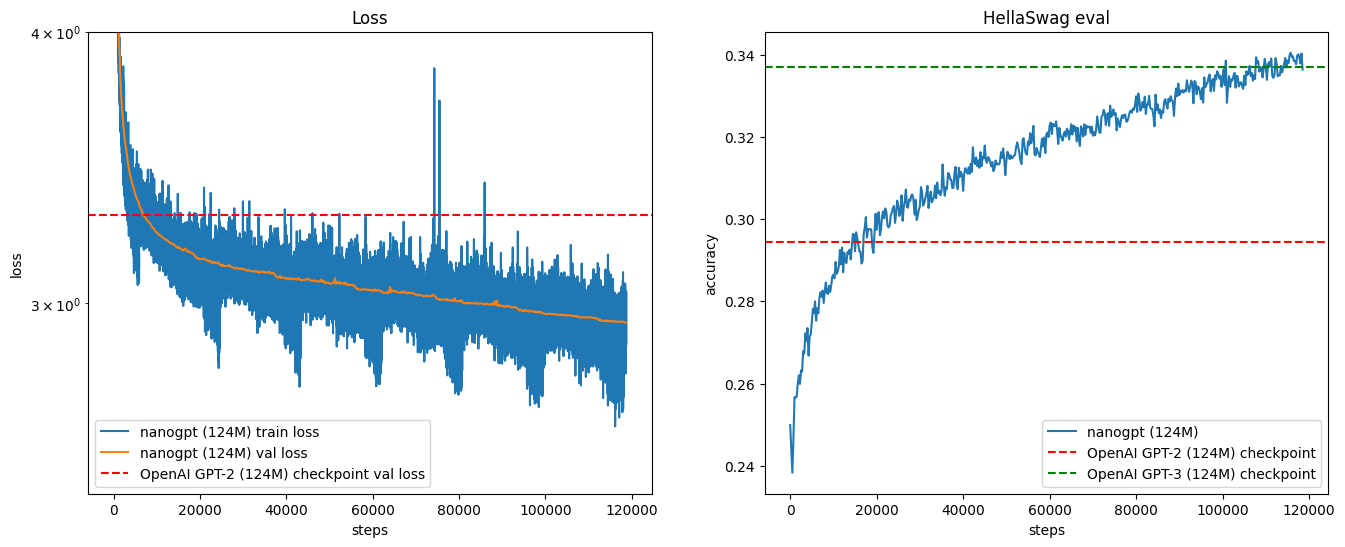

In [13]:
# parse and visualize the logfile
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

sz = "124M"

loss_baseline = {
    "124M": 3.2924,
}[sz]
hella2_baseline = { # HellaSwag for GPT-2
    "124M": 0.294463,
    "350M": 0.375224,
    "774M": 0.431986,
    "1558M": 0.488946,
}[sz]
hella3_baseline = { # HellaSwag for GPT-3
    "124M": 0.337,
    "350M": 0.436,
    "774M": 0.510,
    "1558M": 0.547,
}[sz]

# load the log file
with open("/Users/ammarh/Desktop/karpathy-gpt-log.txt", "r") as f:
    lines = f.readlines()

# parse the individual lines, group by stream (train,val,hella)
streams = {}
for line in lines:
    step, stream, val = line.strip().split()
    if stream not in streams:
        streams[stream] = {}
    streams[stream][int(step)] = float(val)

# convert each stream from {step: val} to (steps[], vals[])
# so it's easier for plotting
streams_xy = {}
for k, v in streams.items():
    # get all (step, val) items, sort them
    xy = sorted(list(v.items()))
    # unpack the list of tuples to tuple of lists
    streams_xy[k] = list(zip(*xy))

# create figure
plt.figure(figsize=(16, 6))

# Panel 1: losses: both train and val
plt.subplot(121)
# we did not log train loss
xs, ys = streams_xy["train"] # training loss
ys = np.array(ys)
plt.plot(xs, ys, label=f'nanogpt ({sz}) train loss')
print("Min Train Loss:", min(ys))
xs, ys = streams_xy["val"] # validation loss
plt.plot(xs, ys, label=f'nanogpt ({sz}) val loss')
# horizontal line at GPT-2 baseline
if loss_baseline is not None:
    plt.axhline(y=loss_baseline, color='r', linestyle='--', label=f"OpenAI GPT-2 ({sz}) checkpoint val loss")
plt.xlabel("steps")
plt.ylabel("loss")
plt.yscale('log')
plt.ylim(top=4.0)
plt.legend()
plt.title("Loss")
print("Min Validation Loss:", min(ys))

# we did not log hella either
# Panel 2: HellaSwag eval
plt.subplot(122)
xs, ys = streams_xy["hella"] # HellaSwag eval
ys = np.array(ys)
plt.plot(xs, ys, label=f"nanogpt ({sz})")
# horizontal line at GPT-2 baseline
if hella2_baseline:
    plt.axhline(y=hella2_baseline, color='r', linestyle='--', label=f"OpenAI GPT-2 ({sz}) checkpoint")
if hella3_baseline:
    plt.axhline(y=hella3_baseline, color='g', linestyle='--', label=f"OpenAI GPT-3 ({sz}) checkpoint")
plt.xlabel("steps")
plt.ylabel("accuracy")
plt.legend()
plt.title("HellaSwag eval")
print("Max Hellaswag eval:", max(ys))

In [17]:
import torch

checkpoint_ammar = torch.load('/Users/ammarh/Desktop/ammar-gpt-model130000.pt', map_location=torch.device('cpu'))
checkpoint_karpathy = torch.load('/Users/ammarh/Desktop/karpathy-gpt-model130000.pt', map_location=torch.device('cpu'))

In [42]:
device = "cpu"

def sample(model, input):
    num_return_seq = 5
    max_length = 30
    torch.manual_seed(42)   
    ## Tokenize input
    import tiktoken
    enc = tiktoken.get_encoding('gpt2')
    tokens = enc.encode(input)
    tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
    tokens = tokens.unsqueeze(0).repeat(num_return_seq, 1) # (5,8)
    x = tokens.to(device)

    model.eval()
    model.to(device)
    while x.size(1) < max_length:
        # forward the model to get the logits
        with torch.no_grad():
            # For our model architecture
            logits, _ = model(x) # (B, T, vocab_size)

            # ## For HuggingFace LMHead
            # out = model(x) # (B, T, vocab_size)
            # logits = out.logits

            # take the logits at the last position
            logits = logits[:, -1, :] # (B, vocab size)

            # get the probabilities
            probs = F.softmax(logits, dim=-1)

            # get the top-k=50 probabilities for sampling
            topk_probs, topk_idcs = torch.topk(probs, 50, dim=-1)
            # select a token for the top-k tokens
            ix = torch.multinomial(topk_probs, 1) # (B, 1)
            # gather the corresponding indices
            xcol = torch.gather(topk_idcs, dim=-1, index=ix) # (B, 1)
            # append to the sequence
            x = torch.cat((x, xcol), dim=1)
            # print(x)

    # print generated text
    for i in range(num_return_seq):
        tokens = x[i, :max_length].tolist()
        decoded = enc.decode(tokens)
        print(">", decoded)

input = "Hello I'm a language model,"

## Initialize a model
model_ammar = GPT(GPTConfig(vocab_size=50304)) # set vocab size a bit larger than tokenizer to make it a nice power of 2 (not an ugly number anymore)
# remove the prefix that got added for distributed training
new_state_dict = {}
for k, v in checkpoint_ammar['model'].items():
    if not k.endswith('.attn.bias'): # ignore these, just got added because i had a register_buffer in my training code which i guess is not needed - compare to the karpathy training file
        new_state_dict[k.replace('_orig_mod.', '')] = v
model_ammar.load_state_dict(new_state_dict)
print("#### Ammar Model ####")
sample(model_ammar, input)

# Karpathy model
model_karpathy = GPT(GPTConfig(vocab_size=50304)) # set vocab size a bit larger than tokenizer to make it a nice power of 2 (not an ugly number anymore)
# remove the prefix that got added for distributed training
new_state_dict = {}
for k, v in checkpoint_karpathy['model'].items():
    new_state_dict[k.replace('_orig_mod.', '')] = v

model_karpathy.load_state_dict(checkpoint_karpathy['model'])
print("#### Karpathy Model ####")
sample(model_karpathy, input)

## Using our GPT model
print("#### OpenAI GPT2 Model ####")
model = GPT.from_pretrained('gpt2')
sample(model, input)

# ## Using our HuggingFace model
# from transformers import GPT2LMHeadModel
# print("#### HuggingFace GPT2 Model ####")

# model = GPT2LMHeadModel.from_pretrained("gpt2")
# sample(model, input)



#### Ammar Model ####
> Hello I'm a language model, I'm trying to use my own language model. That model is what I'm actually trying to teach you. What
> Hello I'm a language model, my friends know nothing about language, my name is pretty much synonymous with language, but I personally, have nothing to
> Hello I'm a language model, how does the language you're modeling it?
"There are two ways you can model," you might say.
> Hello I'm a language model, I understand that the main objective of this course is "to produce the native speaker of a particular language who will help
> Hello I'm a language model, what this is about.
I have developed a number of language models that help you understand all the language concepts needed
#### Karpathy Model ####
> Hello I'm a language model, and I think what I have to do to make sure the computer does work is: I want to run the system
> Hello I'm a language model, I just tried to help someone.
1 of 37 people found this helpful
- Cebollas; "
> Hello